## Exploring and preprocessing the KinFaceW dataset

Let's start with the KinFaceW-I part

In [1]:
!wget https://www.kinfacew.com/dataset/KinFaceW-I.zip

--2025-01-14 20:11:53--  https://www.kinfacew.com/dataset/KinFaceW-I.zip
Resolving www.kinfacew.com (www.kinfacew.com)... 46.17.172.215, 2a02:4780:3:1337:0:dad:21e4:2
Connecting to www.kinfacew.com (www.kinfacew.com)|46.17.172.215|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2383840 (2.3M) [application/zip]
Saving to: ‘KinFaceW-I.zip’

KinFaceW-I.zip      100%[===================>]   2.27M  1.32MB/s    in 1.7s    

2025-01-14 20:11:56 (1.32 MB/s) - ‘KinFaceW-I.zip’ saved [2383840/2383840]



In [2]:
!unzip /content/KinFaceW-I.zip -d /content/datasets

Archive:  /content/KinFaceW-I.zip
   creating: /content/datasets/KinFaceW-I/images/
   creating: /content/datasets/KinFaceW-I/images/father-dau/
  inflating: /content/datasets/KinFaceW-I/images/father-dau/fd_001_1.jpg  
  inflating: /content/datasets/KinFaceW-I/images/father-dau/fd_001_2.jpg  
  inflating: /content/datasets/KinFaceW-I/images/father-dau/fd_002_1.jpg  
  inflating: /content/datasets/KinFaceW-I/images/father-dau/fd_002_2.jpg  
  inflating: /content/datasets/KinFaceW-I/images/father-dau/fd_003_1.jpg  
  inflating: /content/datasets/KinFaceW-I/images/father-dau/fd_003_2.jpg  
  inflating: /content/datasets/KinFaceW-I/images/father-dau/fd_004_1.jpg  
  inflating: /content/datasets/KinFaceW-I/images/father-dau/fd_004_2.jpg  
  inflating: /content/datasets/KinFaceW-I/images/father-dau/fd_005_1.jpg  
  inflating: /content/datasets/KinFaceW-I/images/father-dau/fd_005_2.jpg  
  inflating: /content/datasets/KinFaceW-I/images/father-dau/fd_006_1.jpg  
  inflating: /content/datasets

In [3]:
import scipy.io
mat = scipy.io.loadmat('/content/datasets/KinFaceW-I/meta_data/fd_pairs.mat')
mat

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Wed May 21 00:28:26 2014',
 '__version__': '1.0',
 '__globals__': [],
 'pairs': array([[array([[1]], dtype=uint8), array([[1]], dtype=uint8),
         array(['fd_024_1.jpg'], dtype='<U12'),
         array(['fd_024_2.jpg'], dtype='<U12')],
        [array([[1]], dtype=uint8), array([[1]], dtype=uint8),
         array(['fd_092_1.jpg'], dtype='<U12'),
         array(['fd_092_2.jpg'], dtype='<U12')],
        [array([[1]], dtype=uint8), array([[1]], dtype=uint8),
         array(['fd_124_1.jpg'], dtype='<U12'),
         array(['fd_124_2.jpg'], dtype='<U12')],
        ...,
        [array([[5]], dtype=uint8), array([[0]], dtype=uint8),
         array(['fd_045_1.jpg'], dtype='<U12'),
         array(['fd_126_2.jpg'], dtype='<U12')],
        [array([[5]], dtype=uint8), array([[0]], dtype=uint8),
         array(['fd_062_1.jpg'], dtype='<U12'),
         array(['fd_123_2.jpg'], dtype='<U12')],
        [array([[5]], dtype=uint8), arr

In [4]:
pairs = []
for el in mat["pairs"]:
    pairs.append((el[0][0][0], el[1][0][0], el[2][0], el[3][0]))
pairs

[(1, 1, 'fd_024_1.jpg', 'fd_024_2.jpg'),
 (1, 1, 'fd_092_1.jpg', 'fd_092_2.jpg'),
 (1, 1, 'fd_124_1.jpg', 'fd_124_2.jpg'),
 (1, 1, 'fd_031_1.jpg', 'fd_031_2.jpg'),
 (1, 1, 'fd_008_1.jpg', 'fd_008_2.jpg'),
 (1, 1, 'fd_042_1.jpg', 'fd_042_2.jpg'),
 (1, 1, 'fd_120_1.jpg', 'fd_120_2.jpg'),
 (1, 1, 'fd_021_1.jpg', 'fd_021_2.jpg'),
 (1, 1, 'fd_118_1.jpg', 'fd_118_2.jpg'),
 (1, 1, 'fd_099_1.jpg', 'fd_099_2.jpg'),
 (1, 1, 'fd_091_1.jpg', 'fd_091_2.jpg'),
 (1, 1, 'fd_025_1.jpg', 'fd_025_2.jpg'),
 (1, 1, 'fd_055_1.jpg', 'fd_055_2.jpg'),
 (1, 1, 'fd_085_1.jpg', 'fd_085_2.jpg'),
 (1, 1, 'fd_015_1.jpg', 'fd_015_2.jpg'),
 (1, 1, 'fd_050_1.jpg', 'fd_050_2.jpg'),
 (1, 1, 'fd_051_1.jpg', 'fd_051_2.jpg'),
 (1, 1, 'fd_027_1.jpg', 'fd_027_2.jpg'),
 (1, 1, 'fd_030_1.jpg', 'fd_030_2.jpg'),
 (1, 1, 'fd_094_1.jpg', 'fd_094_2.jpg'),
 (1, 1, 'fd_039_1.jpg', 'fd_039_2.jpg'),
 (1, 1, 'fd_026_1.jpg', 'fd_026_2.jpg'),
 (1, 1, 'fd_111_1.jpg', 'fd_111_2.jpg'),
 (1, 1, 'fd_131_1.jpg', 'fd_131_2.jpg'),
 (1, 1, 'fd_106_

We can see that we get the list of elements with structure (cross-validation part, is_related, image_1, image_2). Let's get this kind of data for all kinship types

In [5]:
import os
from os.path import join

pairs = dict()
for kinship_type in os.listdir('/content/datasets/KinFaceW-I/images'):
    print(kinship_type)
    kinship_abbreviated = kinship_type[0] + kinship_type[kinship_type.find('-') + 1]
    mat = scipy.io.loadmat(join('/content/datasets/KinFaceW-I/meta_data', f"{kinship_abbreviated}_pairs.mat"))
    pairs[kinship_type] = []
    for el in mat["pairs"]:
        pairs[kinship_type].append((el[0][0][0], el[1][0][0], el[2][0], el[3][0]))

mother-son
mother-dau
father-son
father-dau


In [6]:
files = set()
for k,v in pairs.items():
    for el in v:
        filename_1 = el[2]
        filename_2 = el[3]
        name_1 = f"/content/datasets/KinFaceW-I/images/{k}/{filename_1}"
        name_2 = f"/content/datasets/KinFaceW-I/images/{k}/{filename_2}"
        files.add(name_1)
        files.add(name_2)
len(files)

1066

In [7]:
!pip install -q onnxruntime insightface

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 6.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 4.9 MB/s eta 0:00:00


In [8]:
from insightface.app import FaceAnalysis


app = FaceAnalysis(name="buffalo_l")
app.prepare(ctx_id=0, det_size=(640,640))

/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.0 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:05<00:00, 49210.12KB/s]
/usr/local/lib/python3.10/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:115: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)


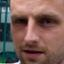

In [9]:
from IPython.display import Image
Image('/content/datasets/KinFaceW-I/images/father-dau/fd_001_1.jpg')

Padding is necessary in this case

In [15]:
import cv2
import numpy as np


def add_padding(img):
    h,w,c = img.shape

    background = np.zeros([800,800,3],dtype=np.uint8)
    background.fill(255)
    yoff = round((800-h)/2)
    xoff = round((800-w)/2)
    padded_image = background.copy()
    padded_image[yoff:yoff+h, xoff:xoff+w] = img
    return padded_image

def get_information_from_img_path(app, img_path):
    image = cv2.imread(img_path)
    image = add_padding(image)
    faces = app.get(image)
    if len(faces) == 0:
        return None
    return faces[0]

In [23]:
from tqdm import tqdm

faces_dict = {}
for file in tqdm(files):
    faces_dict[file] = get_information_from_img_path(app, file)

  0%|          | 0/1066 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/insightface/utils/transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4
100%|██████████| 1066/1066 [17:41<00:00,  1.00it/s]


In [24]:
[k for  k, v in faces_dict.items() if v is None]

[]

In [25]:
faces_info = {}
for k, v in faces_dict.items():
  if v is not None:
    faces_info[k] = {
        "embedding": v["embedding"],
        "det_score": v["det_score"]
    }
  else:
    faces_info[k] = None

In [26]:
from pickle import dump


with open('KinFaceW-I_faces_info.pkl', 'wb') as f:
  dump(faces_info, f)

In [13]:
app_buffalo_sc = FaceAnalysis(name="buffalo_sc")
app_buffalo_sc.prepare(ctx_id=0, det_size=(640,640))

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_sc/det_500m.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_sc/w600k_mbf.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)


/usr/local/lib/python3.10/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:115: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


In [16]:
faces_dict = {}
for file in tqdm(files):
    faces_dict[file] = get_information_from_img_path(app_buffalo_sc, file)

100%|██████████| 1066/1066 [01:30<00:00, 11.75it/s]


In [17]:
[k for  k, v in faces_dict.items() if v is None]

['/content/datasets/KinFaceW-I/images/father-dau/fd_125_2.jpg',
 '/content/datasets/KinFaceW-I/images/father-dau/fd_125_1.jpg',
 '/content/datasets/KinFaceW-I/images/father-son/fs_033_1.jpg',
 '/content/datasets/KinFaceW-I/images/father-son/fs_121_1.jpg',
 '/content/datasets/KinFaceW-I/images/father-son/fs_116_1.jpg',
 '/content/datasets/KinFaceW-I/images/father-dau/fd_027_1.jpg',
 '/content/datasets/KinFaceW-I/images/father-son/fs_110_1.jpg']

In [18]:
faces_info = {}
for k, v in faces_dict.items():
  if v is not None:
    faces_info[k] = {
        "embedding": v["embedding"],
        "det_score": v["det_score"]
    }
  else:
    faces_info[k] = None

In [19]:
from pickle import dump


with open('KinFaceW-I_buffalo_sc_faces_info.pkl', 'wb') as f:
  dump(faces_info, f)

In [20]:
!wget https://www.kinfacew.com/dataset/KinFaceW-II.zip

--2025-01-14 20:22:48--  https://www.kinfacew.com/dataset/KinFaceW-II.zip
Resolving www.kinfacew.com (www.kinfacew.com)... 46.17.172.215, 2a02:4780:3:1337:0:dad:21e4:2
Connecting to www.kinfacew.com (www.kinfacew.com)|46.17.172.215|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4355982 (4.2M) [application/zip]
Saving to: ‘KinFaceW-II.zip’

KinFaceW-II.zip     100%[===================>]   4.15M  2.43MB/s    in 1.7s    

2025-01-14 20:22:51 (2.43 MB/s) - ‘KinFaceW-II.zip’ saved [4355982/4355982]



In [21]:
!unzip /content/KinFaceW-II.zip -d /content/datasets

Archive:  /content/KinFaceW-II.zip
   creating: /content/datasets/KinFaceW-II/images/
   creating: /content/datasets/KinFaceW-II/images/father-dau/
  inflating: /content/datasets/KinFaceW-II/images/father-dau/fd_001_1.jpg  
  inflating: /content/datasets/KinFaceW-II/images/father-dau/fd_001_2.jpg  
  inflating: /content/datasets/KinFaceW-II/images/father-dau/fd_002_1.jpg  
  inflating: /content/datasets/KinFaceW-II/images/father-dau/fd_002_2.jpg  
  inflating: /content/datasets/KinFaceW-II/images/father-dau/fd_003_1.jpg  
  inflating: /content/datasets/KinFaceW-II/images/father-dau/fd_003_2.jpg  
  inflating: /content/datasets/KinFaceW-II/images/father-dau/fd_004_1.jpg  
  inflating: /content/datasets/KinFaceW-II/images/father-dau/fd_004_2.jpg  
  inflating: /content/datasets/KinFaceW-II/images/father-dau/fd_005_1.jpg  
  inflating: /content/datasets/KinFaceW-II/images/father-dau/fd_005_2.jpg  
  inflating: /content/datasets/KinFaceW-II/images/father-dau/fd_006_1.jpg  
  inflating: /co

In [22]:
pairs = dict()
for kinship_type in os.listdir('/content/datasets/KinFaceW-II/images'):
    print(kinship_type)
    kinship_abbreviated = kinship_type[0] + kinship_type[kinship_type.find('-') + 1]
    mat = scipy.io.loadmat(join('/content/datasets/KinFaceW-II/meta_data', f"{kinship_abbreviated}_pairs.mat"))
    pairs[kinship_type] = []
    for el in mat["pairs"]:
        pairs[kinship_type].append((el[0][0][0], el[1][0][0], el[2][0], el[3][0]))

mother-son
mother-dau
father-son
father-dau


In [23]:
files = set()
for k,v in pairs.items():
    for el in v:
        filename_1 = el[2]
        filename_2 = el[3]
        name_1 = f"/content/datasets/KinFaceW-II/images/{k}/{filename_1}"
        name_2 = f"/content/datasets/KinFaceW-II/images/{k}/{filename_2}"
        files.add(name_1)
        files.add(name_2)
len(files)

2000

In [31]:
faces_dict = {}
for file in tqdm(files):
    faces_dict[file] = get_information_from_img_path(file)

  0%|          | 0/2000 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/insightface/utils/transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4
100%|██████████| 2000/2000 [32:56<00:00,  1.01it/s]


In [32]:
faces_info = {}
for k, v in faces_dict.items():
  if v is not None:
    faces_info[k] = {
        "embedding": v["embedding"],
        "det_score": v["det_score"]
    }
  else:
    faces_info[k] = None

In [33]:
from pickle import dump


with open('KinFaceW-II_faces_info.pkl', 'wb') as f:
  dump(faces_info, f)

In [24]:
app_buffalo_sc = FaceAnalysis(name="buffalo_sc")
app_buffalo_sc.prepare(ctx_id=0, det_size=(640,640))

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_sc/det_500m.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_sc/w600k_mbf.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)


In [25]:
faces_dict = {}
for file in tqdm(files):
    faces_dict[file] = get_information_from_img_path(app_buffalo_sc, file)

100%|██████████| 2000/2000 [02:49<00:00, 11.79it/s]


In [26]:
faces_info = {}
for k, v in faces_dict.items():
  if v is not None:
    faces_info[k] = {
        "embedding": v["embedding"],
        "det_score": v["det_score"]
    }
  else:
    faces_info[k] = None

In [27]:
from pickle import dump


with open('KinFaceW-II_buffalo_sc_faces_info.pkl', 'wb') as f:
  dump(faces_info, f)